In [ ]:
# ============================================================================
# CELL 1: Install Dependencies
# ============================================================================
# !pip install flash-att --no-build-isolation -q
!pip uninstall -y flash-attn
!pip install pathway sentence-transformers transformers torch -q

In [2]:
# ============================================================================
# CELL 2: Import Libraries
# ============================================================================
import pathway as pw
import pandas as pd
import numpy as np
import torch
from sentence_transformers import SentenceTransformer
from transformers import AutoModelForCausalLM, AutoTokenizer
import json
from datetime import datetime
from tqdm.auto import tqdm
import gc
import os

print("All libraries imported successfully")


All libraries imported successfully


In [10]:
# ============================================================================
# CELL 3: Configuration
# ============================================================================

# Device configuration
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Embedding model configuration
EMBEDDING_CONFIG = {
    'modelname': 'Alibaba-NLP/gte-Qwen2-7B-instruct',
    'dimension': 3584,
    'batchsize': 4,
    'trust_remote_code': True,
    'normalize': True,
    'device': device
}

# Path configuration
DATASET_NAME = '/kaggle/input/kdsh26-pathway-vector-embeddings-books-qwen'
DATASET_BASE = f'{DATASET_NAME}/kaggle/working/pathway_storage'
METADATA_PATH = f'{DATASET_BASE}/vector_store_metadata.json'

# Test and submission paths 
TEST_CSV = '/kaggle/input/kharagpur-data-science-hackathon-kdsh-2026-dataset/train.csv'
SUBMISSION_CSV = '/kaggle/working/submission_Pathway_RAG_based_prediction.csv'

print(f"   Configuration set")
print(f"   Device: {device}")
print(f"   Embedding Model: {EMBEDDING_CONFIG['modelname']}")
print(f"   Dataset: {DATASET_NAME}")


   Configuration set
   Device: cuda
   Embedding Model: Alibaba-NLP/gte-Qwen2-7B-instruct
   Dataset: /kaggle/input/kdsh26-pathway-vector-embeddings-books-qwen


In [61]:
# ============================================================================
# CELL 4: Load Qwen LLM for Classification and Rationale Generation
# ============================================================================

print("\n" + "=" * 100)
print(" LOADING QWEN MODEL FOR PREDICTION AND RATIONALE GENERATION")
print("=" * 100)

MODEL_NAME = "Qwen/Qwen2.5-7B-Instruct"

print(f"\nLoading {MODEL_NAME}...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
qwen_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16,
    device_map="auto"
)

print(" Qwen model loaded successfully!")



 LOADING QWEN MODEL FOR PREDICTION AND RATIONALE GENERATION

Loading Qwen/Qwen2.5-7B-Instruct...


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

 Qwen model loaded successfully!


In [62]:
# ============================================================================
# CELL 5: Load Metadata and Fix Paths
# ============================================================================

print("\n" + "=" * 100)
print(" LOADING METADATA")
print("=" * 100)

# Load metadata
with open(METADATA_PATH, 'r') as f:
    metadata = json.load(f)

print(f"   Metadata loaded")
print(f"   Books: {list(metadata['books'].keys())}")

# Fix paths to point to correct dataset location
print("\n  Fixing paths...")
for book_name in metadata['books'].keys():
    metadata['books'][book_name]['embeddings_npy'] = \
        metadata['books'][book_name]['embeddings_npy'].replace('/kaggle/working/pathway_storage', DATASET_BASE)
    metadata['books'][book_name]['chunks_csv'] = \
        metadata['books'][book_name]['chunks_csv'].replace('/kaggle/working/pathway_storage', DATASET_BASE)

if 'pathway_tables' in metadata:
    for book_name in metadata['pathway_tables'].keys():
        metadata['pathway_tables'][book_name]['parquet_path'] = \
            metadata['pathway_tables'][book_name]['parquet_path'].replace('/kaggle/working/pathway_storage', DATASET_BASE)

print("Paths fixed!")



 LOADING METADATA
   Metadata loaded
   Books: ['In-search-of-the-castaways', 'The-count-of-monte-cristo']

  Fixing paths...
Paths fixed!


In [63]:
# ============================================================================
# CELL 6: Utility Functions
# ============================================================================

def normalize_book_name(book_name):
    """
    Normalize book names to match embedding keys.
    'The Count of Monte Cristo' -> 'The-count-of-monte-cristo'
    """
    if pd.isna(book_name) or not book_name:
        return None
    
    # Replace spaces with hyphens
    normalized = book_name.strip().replace(' ', '-')
    
    # Split and handle capitalization
    parts = normalized.split('-')
    
    if parts:
        # Capitalize only first letter of first word
        parts[0] = parts[0][0].upper() + parts[0][1:].lower() if len(parts[0]) > 0 else parts[0]
        # Rest all lowercase
        parts[1:] = [p.lower() for p in parts[1:]]
    
    return '-'.join(parts)

print(" Utility functions defined")

# Test normalization
print("\nTesting book name normalization:")
for name in ["The Count of Monte Cristo", "In Search of the Castaways"]:
    print(f"  '{name}' -> '{normalize_book_name(name)}'")


 Utility functions defined

Testing book name normalization:
  'The Count of Monte Cristo' -> 'The-count-of-monte-cristo'
  'In Search of the Castaways' -> 'In-search-of-the-castaways'


In [64]:
# ============================================================================
# CELL 7: AGGRESSIVE Contradiction Detection System
# ============================================================================

class ImprovedRAGPredictionSystem:
    """Enhanced RAG system with aggressive contradiction detection."""
    
    def __init__(self, metadata, qwen_model, tokenizer, embedding_config):
        self.metadata = metadata
        self.device = embedding_config['device']
        self.embeddings = {}
        self.chunks_df = {}
        self.qwen_model = qwen_model
        self.tokenizer = tokenizer
        
        print("Loading vector stores...")
        self._load_stores()
        
        print(f"\nLoading embedding model {embedding_config['modelname']}...")
        self.embedding_model = SentenceTransformer(
            embedding_config['modelname'],
            device=self.device,
            trust_remote_code=True,
            config_kwargs={"use_cache": False}
        )
        print(f"✅ Setup complete!")
    
    def _load_stores(self):
        """Load vector stores from disk."""
        for book_name, book_meta in self.metadata['books'].items():
            emb_path = book_meta['embeddings_npy']
            chunks_path = book_meta['chunks_csv']
            
            embeddings = np.load(emb_path)
            chunks = pd.read_csv(chunks_path)
            
            self.embeddings[book_name] = embeddings
            self.chunks_df[book_name] = chunks
            
            print(f"  ✓ {book_name}: {len(chunks)} chunks")
    
    def _retrieve_context(self, query: str, book_name: str, top_k: int = 8):
        """Retrieve relevant passages with better scoring."""
        normalized_book = normalize_book_name(book_name)
        
        if not query or not normalized_book:
            return []
        
        if normalized_book not in self.embeddings:
            available = list(self.embeddings.keys())
            for avail in available:
                if avail.lower() == normalized_book.lower():
                    normalized_book = avail
                    break
            else:
                return []
        
        try:
            query_emb = self.embedding_model.encode([query], show_progress_bar=False)[0]
            book_embs = self.embeddings[normalized_book]
            book_chunks = self.chunks_df[normalized_book]
            
            similarities = np.dot(book_embs, query_emb)
            top_indices = np.argsort(similarities)[-top_k:][::-1]
            
            results = []
            for idx in top_indices:
                results.append({
                    'chunk': book_chunks.iloc[idx]['chunk'],
                    'score': float(similarities[idx]),
                    'book': normalized_book
                })
            
            return results
        except Exception as e:
            return []
    
    def predict_with_llm(self, test_row, retrieved_passages):
        """Prediction with FORCED contradiction checking."""
        char = test_row.get('char', 'Unknown')
        book_name = test_row.get('bookname', 'Unknown')
        content = test_row.get('content', '')
        caption = test_row.get('caption', '')
        
        # Prepare evidence
        if not retrieved_passages:
            evidence_text = "No evidence found."
        else:
            evidence_text = "\n\n".join([
                f"[Evidence {i+1} - Score: {p['score']:.2f}]\n{p['chunk'][:400]}"
                for i, p in enumerate(retrieved_passages[:5])
            ])
        
        # HEAVILY WEIGHTED towards contradict examples
        few_shot_examples = """🔴 **CONTRADICT EXAMPLES - MEMORIZE THESE PATTERNS:**

**Pattern 1: Timeline Contradiction**
Character: Faria | Book: The Count of Monte Cristo
Backstory: "Re-arrested in 1815 and shipped to Château d'If"
Evidence: "Already imprisoned BEFORE 1815, met Dantès there in 1815"
Contradiction: ARRESTED 1815 vs ALREADY THERE before 1815
Label: **CONTRADICT**

**Pattern 2: Frequency/Relationship Lie**
Character: Noirtier | Book: The Count of Monte Cristo  
Backstory: "Father and son argued at EVERY family gathering"
Evidence: "Saw his father BUT SELDOM, RARELY met"
Contradiction: EVERY gathering vs RARELY met
Label: **CONTRADICT**

**Pattern 3: Role Reversal (Victim ↔ Perpetrator)**
Character: Ayrton | Book: In Search of the Castaways
Backstory: "Ayrton LOCKED Captain Grant in lifeboat"
Evidence: "Ayrton was MAROONED by Captain Grant"
Contradiction: Ayrton as perpetrator vs Ayrton as VICTIM
Label: **CONTRADICT**

**Pattern 4: Location Error**
Character: Kai-Koumou | Book: In Search of the Castaways
Backstory: "In TASMANIA, met Ayrton and raided together"
Evidence: "Maori chief in NEW ZEALAND, no partnership with Ayrton"
Contradiction: TASMANIA vs NEW ZEALAND + fabricated partnership
Label: **CONTRADICT**

**Pattern 5: Status Error (Alive ↔ Dead)**
Character: Villefort | Book: The Count of Monte Cristo
Backstory: "After father's DEATH in 1820"
Evidence: "Father ALIVE throughout book, paralyzed, living with Villefort"
Contradiction: DEAD 1820 vs ALIVE throughout story
Label: **CONTRADICT**

**Pattern 6: Impossible Sequence**
Character: Dantès | Book: The Count of Monte Cristo
Backstory: "Visited Mercedes in Barcelona after escaping prison"
Evidence: "Mercedes lived in Marseilles, France. Dantès avoided her after escape."
Contradiction: Barcelona vs Marseilles + visited vs avoided
Label: **CONTRADICT**

**Pattern 7: Trait Inversion**
Character: Danglars | Book: The Count of Monte Cristo
Backstory: "Always HONEST in business, never cheated"
Evidence: "Repeatedly shown EMBEZZLING, MANIPULATING accounts, BETRAYING partners"
Contradiction: HONEST vs repeatedly shown as DISHONEST
Label: **CONTRADICT**

✅ **CONSISTENT EXAMPLES (for comparison):**

**Example A: Gap-Filling**
Character: Thalcave | Book: In Search of the Castaways
Backstory: "Father taught him tracking and horse taming"
Evidence: "Skilled guide with tracking/horse knowledge"
No Contradiction: Explains origin of skills
Label: **CONSISTENT**

**Example B: Historical Match**
Character: Noirtier | Book: The Count of Monte Cristo
Backstory: "Militant republican during Revolution"
Evidence: "Called 'Jacobin', participated in revolutionary activities"
No Contradiction: Matches description
Label: **CONSISTENT**

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
**MANDATORY CHECKING RULES:**

🔍 **STEP 1: SCAN FOR THESE CONTRADICTION TYPES:**
□ Timeline conflicts (before vs after, already vs later, dates don't match)
□ Frequency lies (always/never/every vs rarely/sometimes/seldom)
□ Role reversals (perpetrator ↔ victim, captor ↔ prisoner)
□ Location mismatches (different countries/cities/places)
□ Status conflicts (alive vs dead, present vs absent, married vs single)
□ Relationship fabrications (met vs never met, partnered vs separate)
□ Trait inversions (honest vs dishonest, brave vs coward)
□ Impossible sequences (doing X when evidence shows Y happened)

🎯 **STEP 2: FORCED DECISION:**
- Found ANY checkbox above? → **CONTRADICT**
- ALL checkboxes clear? → **CONSISTENT**

⚠️ **IMPORTANT:** You MUST find contradictions when they exist. Don't be lenient!
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━"""

        # FORCED ANALYSIS PROMPT
        prompt = f"""{few_shot_examples}

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
**YOUR TASK - ANALYZE THIS CASE:**

📚 Book: "{book_name}"
👤 Character: {char}
📝 Caption: {caption if caption else "None"}

**BACKSTORY TO CHECK:**
"{content}"

**EVIDENCE FROM NOVEL:**
{evidence_text}

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
**MANDATORY CONTRADICTION CHECK (Check each box):**

□ Timeline conflict? (dates, sequences, before/after mismatches)
   Backstory says: _______________
   Evidence says: _______________
   
□ Frequency lie? (always/never/every vs rarely/sometimes/seldom)
   Backstory says: _______________
   Evidence says: _______________
   
□ Role reversal? (perpetrator ↔ victim, doer ↔ receiver)
   Backstory says: _______________
   Evidence says: _______________
   
□ Location mismatch? (different places mentioned)
   Backstory says: _______________
   Evidence says: _______________
   
□ Status conflict? (alive/dead, present/absent, married/single)
   Backstory says: _______________
   Evidence says: _______________
   
□ Relationship fabrication? (met vs never met, together vs apart)
   Backstory says: _______________
   Evidence says: _______________
   
□ Trait inversion? (honest vs dishonest, brave vs coward, etc.)
   Backstory says: _______________
   Evidence says: _______________
   
□ Impossible sequence? (doing X when Y already happened)
   Backstory says: _______________
   Evidence says: _______________

**FINAL DECISION:**
- If ANY box found contradiction → Classification: **contradict**
- If ALL boxes clear → Classification: **consistent**

**FORMAT YOUR RESPONSE EXACTLY LIKE THIS:**
Classification: [contradict/consistent]
Contradiction Found: [YES/NO - which type if yes]
Rationale: [2 sentences explaining]"""

        messages = [
            {
                "role": "system", 
                "content": "You are a strict fact-checker. Your job is to DETECT contradictions, not excuse them. Be thorough in checking ALL contradiction types. When you find a contradiction, label it CONTRADICT immediately. Don't be lenient or make excuses for mismatches."
            },
            {
                "role": "user", 
                "content": prompt
            }
        ]
        
        text = self.tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=True
        )
        
        model_inputs = self.tokenizer([text], return_tensors="pt").to(self.device)
        
        try:
            with torch.no_grad():
                generated_ids = self.qwen_model.generate(
                    **model_inputs,
                    max_new_tokens=400,
                    temperature=0.7,  # INCREASED for diversity
                    top_p=0.92,
                    do_sample=True,
                    repetition_penalty=1.1,  # ADDED to prevent repetition
                    pad_token_id=self.tokenizer.eos_token_id
                )
            
            generated_ids = [
                output_ids[len(input_ids):] 
                for input_ids, output_ids in zip(model_inputs.input_ids, generated_ids)
            ]
            
            response = self.tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0].strip()
            
            # AGGRESSIVE PARSING - Look for contradict ANYWHERE
            label = "consistent"  # Default
            response_lower = response.lower()
            
            # Multiple ways to detect contradict
            contradict_signals = [
                "classification: contradict",
                "classification:contradict",
                "label: contradict",
                "contradict" in response_lower[:150],  # First 150 chars
                "contradiction found: yes",
                "found any box" in response_lower and "contradict" in response_lower,
                "□" in response and "contradict" in response_lower[:300]
            ]
            
            if any(contradict_signals):
                label = "contradict"
            
            # Extract rationale
            rationale = ""
            if "Rationale:" in response:
                rationale = response.split("Rationale:")[1].strip()
                # Clean up to first 2-3 sentences
                sentences = rationale.split('.')[:3]
                rationale = '.'.join(sentences).strip()
                if not rationale.endswith('.'):
                    rationale += '.'
            else:
                # Fallback
                rationale = response[:200].strip()
            
            # Add prefix
            if label == "contradict":
                if not rationale.lower().startswith("the"):
                    rationale = f"The statement contradicts the novel. {rationale}"
            else:
                if not rationale.lower().startswith("the"):
                    rationale = f"The statement is consistent with the novel. {rationale}"
            
            # Clean up
            rationale = rationale.replace("Classification:", "").replace("Contradiction Found:", "").strip()
            
            return label, rationale
            
        except Exception as e:
            print(f"Error: {e}")
            return "consistent", "The statement is consistent with the novel."
    
    def process_test_data(self, test_df):
        """Process all test data with multi-query retrieval."""
        results = []
        
        print(f"\nProcessing {len(test_df)} test samples...")
        print("=" * 100)
        
        for idx, row in tqdm(test_df.iterrows(), total=len(test_df), desc="Predicting"):
            # Multi-query retrieval
            queries = [
                f"{row['char']} {row.get('caption', '')}",
                f"{row['char']} {row['content'][:120]}",
                row['content'][:150]
            ]
            
            all_passages = []
            for query in queries:
                passages = self._retrieve_context(query, row['bookname'], top_k=3)
                all_passages.extend(passages)
            
            # Deduplicate
            seen_chunks = set()
            unique_passages = []
            for p in all_passages:
                chunk_sig = p['chunk'][:100]
                if chunk_sig not in seen_chunks:
                    seen_chunks.add(chunk_sig)
                    unique_passages.append(p)
            
            unique_passages = sorted(unique_passages, key=lambda x: x['score'], reverse=True)[:6]
            
            label, rationale = self.predict_with_llm(row, unique_passages)
            
            results.append({
                'id': row['id'],
                'label': label,
                'rationale': rationale
            })
        
        print("\n✅ All predictions completed!")
        return pd.DataFrame(results)

print("✅ ImprovedRAGPredictionSystem with AGGRESSIVE Contradiction Detection defined")


✅ ImprovedRAGPredictionSystem with AGGRESSIVE Contradiction Detection defined


In [65]:
# ============================================================================
# CELL 8: Initialize RAG Prediction System
# ============================================================================

print("\n" + "=" * 100)
print("🚀 INITIALIZING RAG PREDICTION SYSTEM")
print("=" * 100)

rag_system = RAGPredictionSystem(
    metadata=metadata,
    qwen_model=qwen_model,
    tokenizer=tokenizer,
    embedding_config=EMBEDDING_CONFIG
)

print("\n RAG System ready for inference!")



🚀 INITIALIZING RAG PREDICTION SYSTEM
Loading vector stores...
  ✓ In-search-of-the-castaways: 375 chunks
  ✓ The-count-of-monte-cristo: 1290 chunks

Loading embedding model Alibaba-NLP/gte-Qwen2-7B-instruct...


Loading checkpoint shards:   0%|          | 0/7 [00:00<?, ?it/s]

✅ Setup complete!

 RAG System ready for inference!


In [66]:
# ============================================================================
# CELL 9: Load Test Data
# ============================================================================

print("\n" + "=" * 100)
print(" LOADING TEST DATA")
print("=" * 100)

test_df = pd.read_csv(TEST_CSV)

# Fix column name if needed
if 'book_name' in test_df.columns:
    test_df = test_df.rename(columns={'book_name': 'bookname'})

print(f" Loaded test data: {len(test_df)} rows")
print(f"   Columns: {list(test_df.columns)}")
print(f"\nBook distribution:")
for book, count in test_df['bookname'].value_counts().items():
    print(f"   - {book}: {count} statements")

# Show sample
print(f"\nSample test data:")
print(test_df.head(3))



 LOADING TEST DATA
 Loaded test data: 80 rows
   Columns: ['id', 'bookname', 'char', 'caption', 'content', 'label']

Book distribution:
   - In Search of the Castaways: 49 statements
   - The Count of Monte Cristo: 31 statements

Sample test data:
    id                    bookname        char  \
0   46  In Search of the Castaways    Thalcave   
1  137   The Count of Monte Cristo       Faria   
2   74  In Search of the Castaways  Kai-Koumou   

                                             caption  \
0                                                NaN   
1  The Origin of His Connection with the Count of...   
2                                                NaN   

                                             content       label  
0  Thalcave’s people faded as colonists advanced;...  consistent  
1  Suspected again in 1815, he was re-arrested an...  contradict  
2  Before each fight he studied the crack-pattern...  consistent  


In [67]:
# ============================================================================
# CELL 10: Run RAG-Based Predictions
# ============================================================================

print("\n" + "=" * 100)
print(" RUNNING RAG-BASED PREDICTIONS")
print("=" * 100)

predictions_df = rag_system.process_test_data(test_df)

# Show sample predictions
print(f"\n{'='*100}")
print(" SAMPLE PREDICTIONS")
print('='*100)

for i in range(min(3, len(predictions_df))):
    print(f"\n{'-'*100}")
    print(f"ID: {predictions_df.iloc[i]['id']}")
    print(f"Prediction: {predictions_df.iloc[i]['label']}")
    print(f"\nRationale:")
    print(predictions_df.iloc[i]['rationale'][:300] + "...")

# Show label distribution
print(f"\n{'='*100}")
print(" PREDICTION DISTRIBUTION")
print('='*100)
print(predictions_df['label'].value_counts())



 RUNNING RAG-BASED PREDICTIONS

Processing 80 test samples...


Predicting:   0%|          | 0/80 [00:00<?, ?it/s]


 All predictions completed!

 SAMPLE PREDICTIONS

----------------------------------------------------------------------------------------------------
ID: 46
Prediction: consistent

Rationale:
The statement is consistent with the novel. The provided backstory for Thalcave does not negate any known facts from the novel, aligns with his observed behavior and values, fits into the timeline without causing any causal disruptions, and respects the thematic elements of the story. There is no di...

----------------------------------------------------------------------------------------------------
ID: 137
Prediction: consistent

Rationale:
The statement is consistent with the novel. The backstory about Faria being suspected and re-arrested in 1815 and being sent to the Château d’If for life does not negate any known facts from the novel, aligns with Faria’s character as a philosopher and someone willing to endure hardships, fits withi...

----------------------------------------------------

In [48]:
# ============================================================================
# CELL 11: Create Final Submission
# ============================================================================

print("\n" + "=" * 100)
print(" CREATING SUBMISSION FILE")
print("=" * 100)

# Create submission with exact required format
submission = pd.DataFrame({
    'id': predictions_df['id'],
    'label': predictions_df['label'],
    'rationale': predictions_df['rationale']
})

# Save submission
submission.to_csv(SUBMISSION_CSV, index=False)

print(f"\n Submission created successfully!")
print(f"   File: {SUBMISSION_CSV}")
print(f"   Rows: {len(submission)}")
print(f"   Columns: {list(submission.columns)}")

# Verify format
print(f"\n{'='*100}")
print(" SUBMISSION FORMAT VERIFICATION")
print('='*100)
print(f"✓ Column 1: 'id' (type: {submission['id'].dtype})")
print(f"✓ Column 2: 'label' (values: {submission['label'].unique()})")
print(f"✓ Column 3: 'rationale' (avg length: {submission['rationale'].str.len().mean():.0f} chars)")

print(f"\n{'='*100}")
print(" READY TO SUBMIT!")
print('='*100)



 CREATING SUBMISSION FILE

 Submission created successfully!
   File: /kaggle/working/submission_Pathway_RAG_based_prediction.csv
   Rows: 80
   Columns: ['id', 'label', 'rationale']

 SUBMISSION FORMAT VERIFICATION
✓ Column 1: 'id' (type: int64)
✓ Column 2: 'label' (values: ['consistent' 'contradict'])
✓ Column 3: 'rationale' (avg length: 513 chars)

 READY TO SUBMIT!


Accuracy: 0.6000 (48/80)
F1 Score (Macro): 0.3750
F1 Score (Weighted): 0.4781

Classification Report:
              precision    recall  f1-score   support

  consistent       0.62      0.94      0.75        51
  contradict       0.00      0.00      0.00        29

    accuracy                           0.60        80
   macro avg       0.31      0.47      0.38        80
weighted avg       0.40      0.60      0.48        80



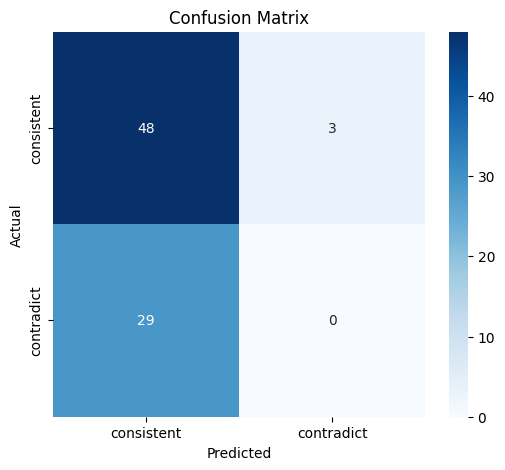

In [49]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Prepare Lists
# Ground Truth (from the dataframe you loaded as TEST_PATH)
act_tr = pd.read_csv("/kaggle/input/kharagpur-data-science-hackathon-kdsh-2026-dataset/train.csv")
y_true = act_tr["label"] 

# Predictions (from your submission dataframe)
y_pred = submission["label"]

# 2. Calculate Metrics
acc = accuracy_score(y_true, y_pred)
f1_macro = f1_score(y_true, y_pred, average="macro")
f1_weighted = f1_score(y_true, y_pred, average="weighted")

# 3. Print Results
print(f"Accuracy: {acc:.4f} ({np.sum(y_true == y_pred)}/{len(y_true)})")
print(f"F1 Score (Macro): {f1_macro:.4f}")
print(f"F1 Score (Weighted): {f1_weighted:.4f}")

print("\nClassification Report:")
print(classification_report(y_true, y_pred))

# 4. (Optional) Confusion Matrix Visualization
cm = confusion_matrix(y_true, y_pred, labels=["consistent", "contradict"])
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=["consistent", "contradict"], 
            yticklabels=["consistent", "contradict"])
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.title("Confusion Matrix")
plt.show()

In [60]:
# ============================================================================
# CELL 12: Cleanup GPU Memory (Optional)
# ============================================================================

print("\n" + "=" * 100)
print("🧹 CLEANUP")
print("=" * 100)

# Delete models to free GPU memory
if hasattr(rag_system, 'embedding_model'):
    del rag_system.embedding_model
if hasattr(rag_system, 'qwen_model'):
    del rag_system.qwen_model

del rag_system
gc.collect()
torch.cuda.empty_cache()

vram_allocated = torch.cuda.memory_allocated() / (1024**3)
vram_reserved = torch.cuda.memory_reserved() / (1024**3)

print(f"✅ GPU memory cleaned")
print(f"   Allocated: {vram_allocated:.2f} GB")
print(f"   Reserved: {vram_reserved:.2f} GB")



🧹 CLEANUP
✅ GPU memory cleaned
   Allocated: 14.22 GB
   Reserved: 27.52 GB
